## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso, Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.feature_selection import SelectKBest
np.set_printoptions(suppress=True)
pd.set_option('display.max_rows',None)
pd.set_option('display.width',1000)
from sklearn.neural_network import MLPRegressor

/home/anshul/Documents/anaconda3/envs/kaggle/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


## Load Data

In [2]:
train = pd.DataFrame(pd.read_csv('./house-prices-advanced-regression-techniques/train.csv'))
test = pd.DataFrame(pd.read_csv('./house-prices-advanced-regression-techniques/test.csv'))

label = train['SalePrice']
train.drop(columns=['SalePrice'],inplace=True)

## Dataset Overview

In [3]:
print(train.info(),'\n')
print(test.info())

print(train.describe().T,'\n')
print(test.describe().T)

print(pd.concat([train.isnull().sum(),test.isnull().sum()],axis=1,keys=['Train','Test']))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Data Visualization

#### Histogram representation of every numerical feature

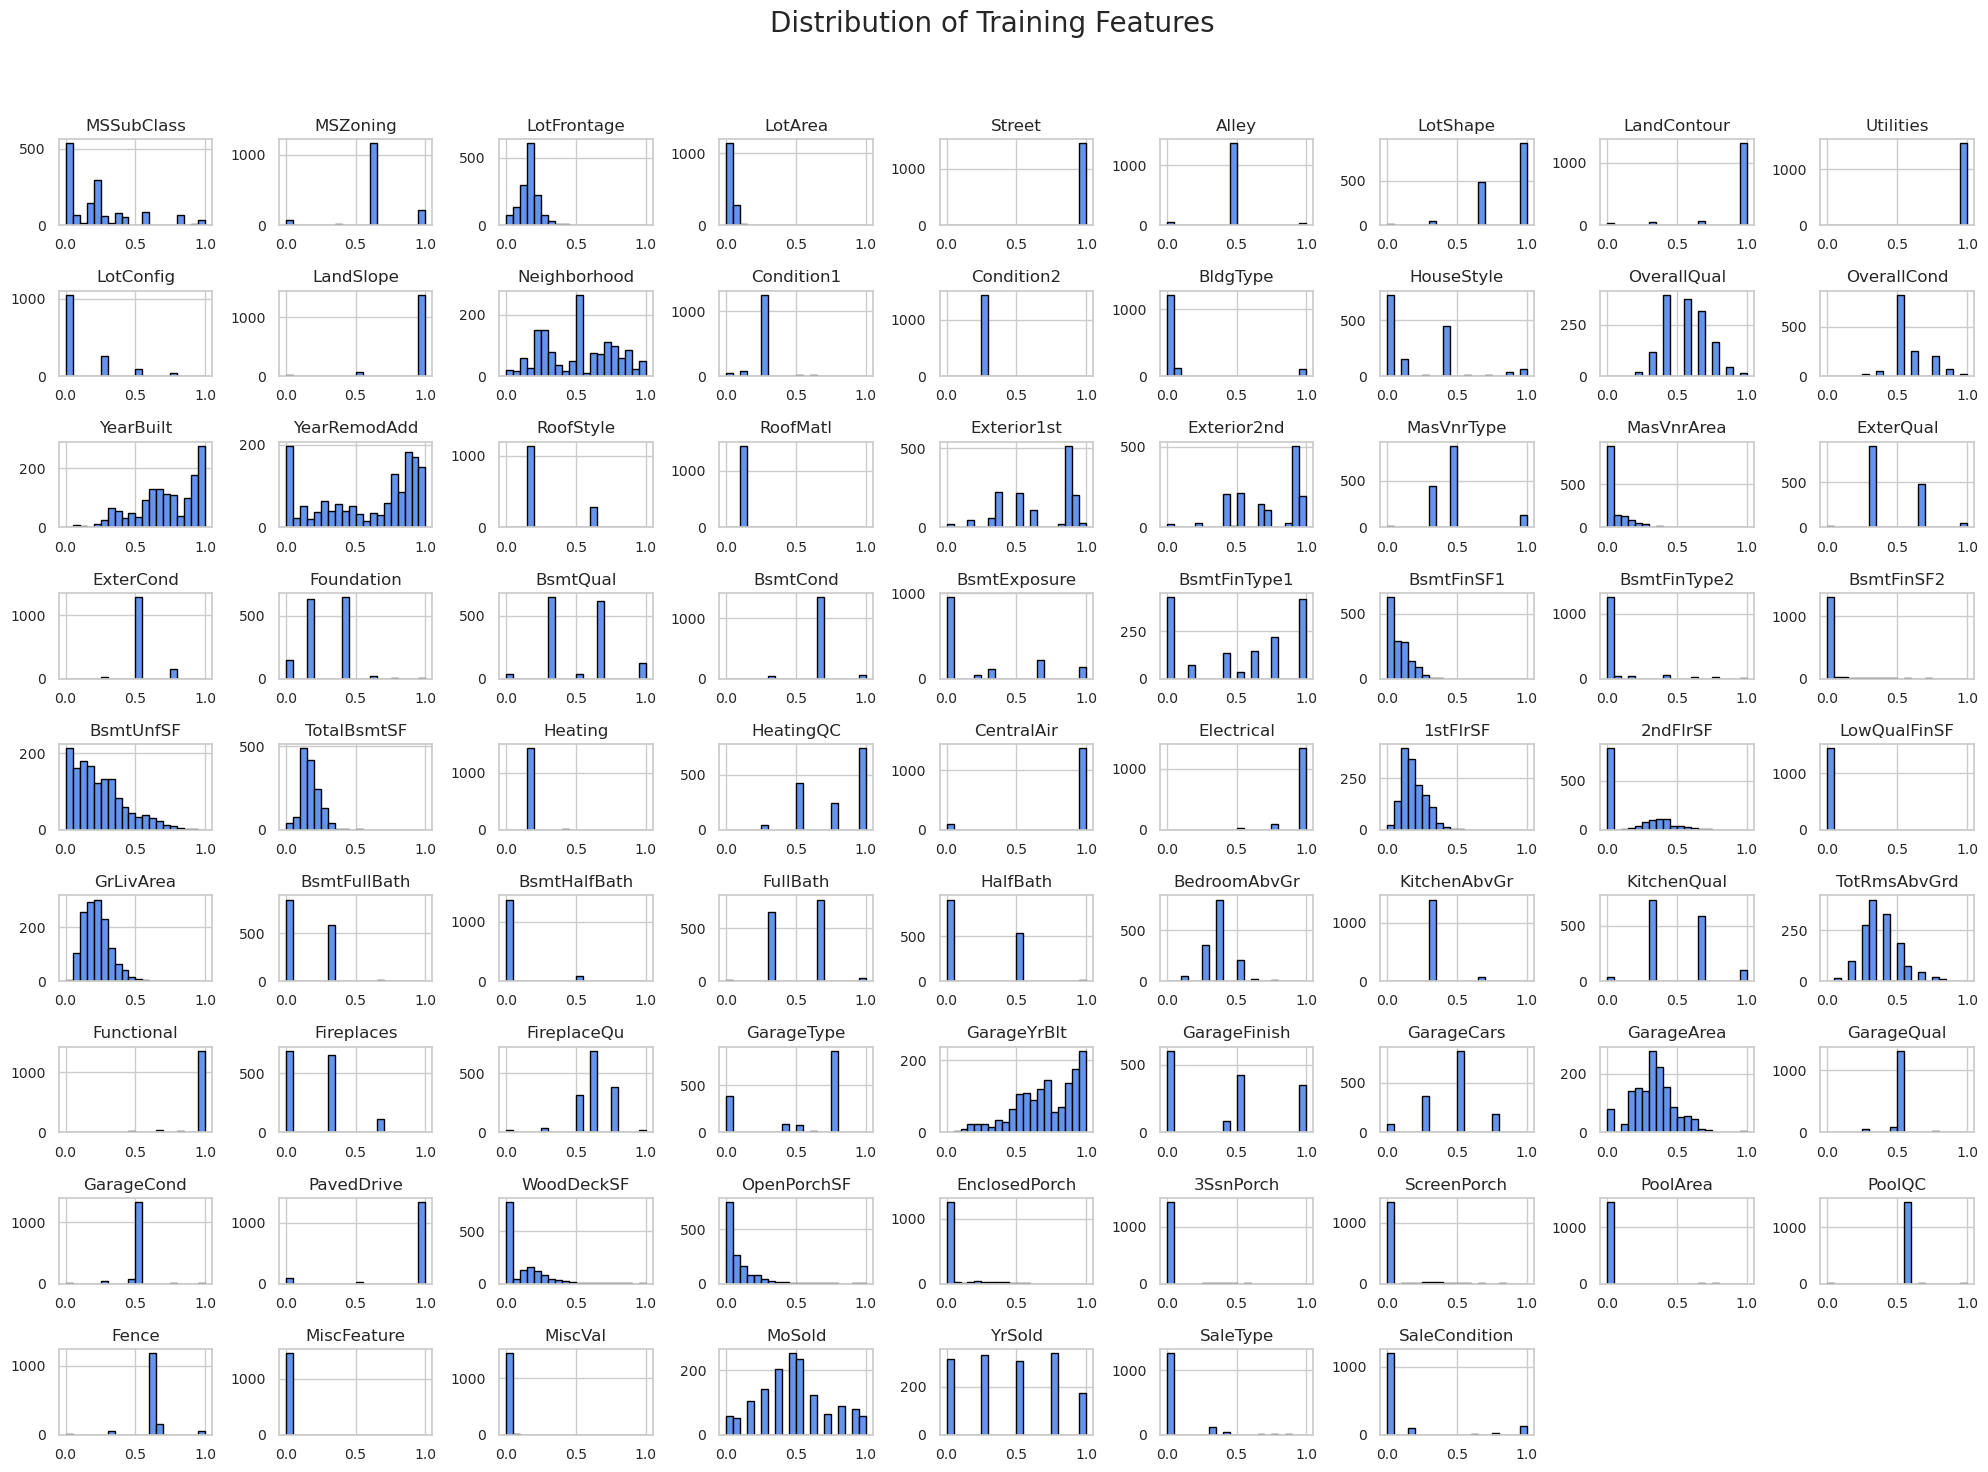

<Figure size 640x480 with 0 Axes>

In [32]:
train.hist(figsize=(20, 15), bins=20, xlabelsize=10, ylabelsize=10, color='cornflowerblue', edgecolor='black')
plt.suptitle('Distribution of Training Features', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
plt.tight_layout()
plt.show()

#### Sales Price distribution

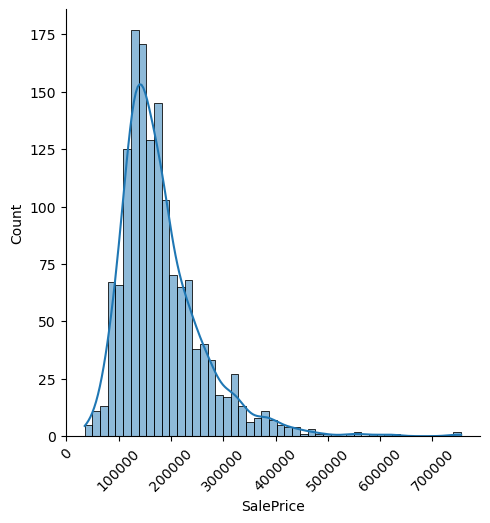

In [5]:
sns.displot(label,kde=True)
plt.xticks(rotation=45)
plt.show()

#### Sale Price vs different features

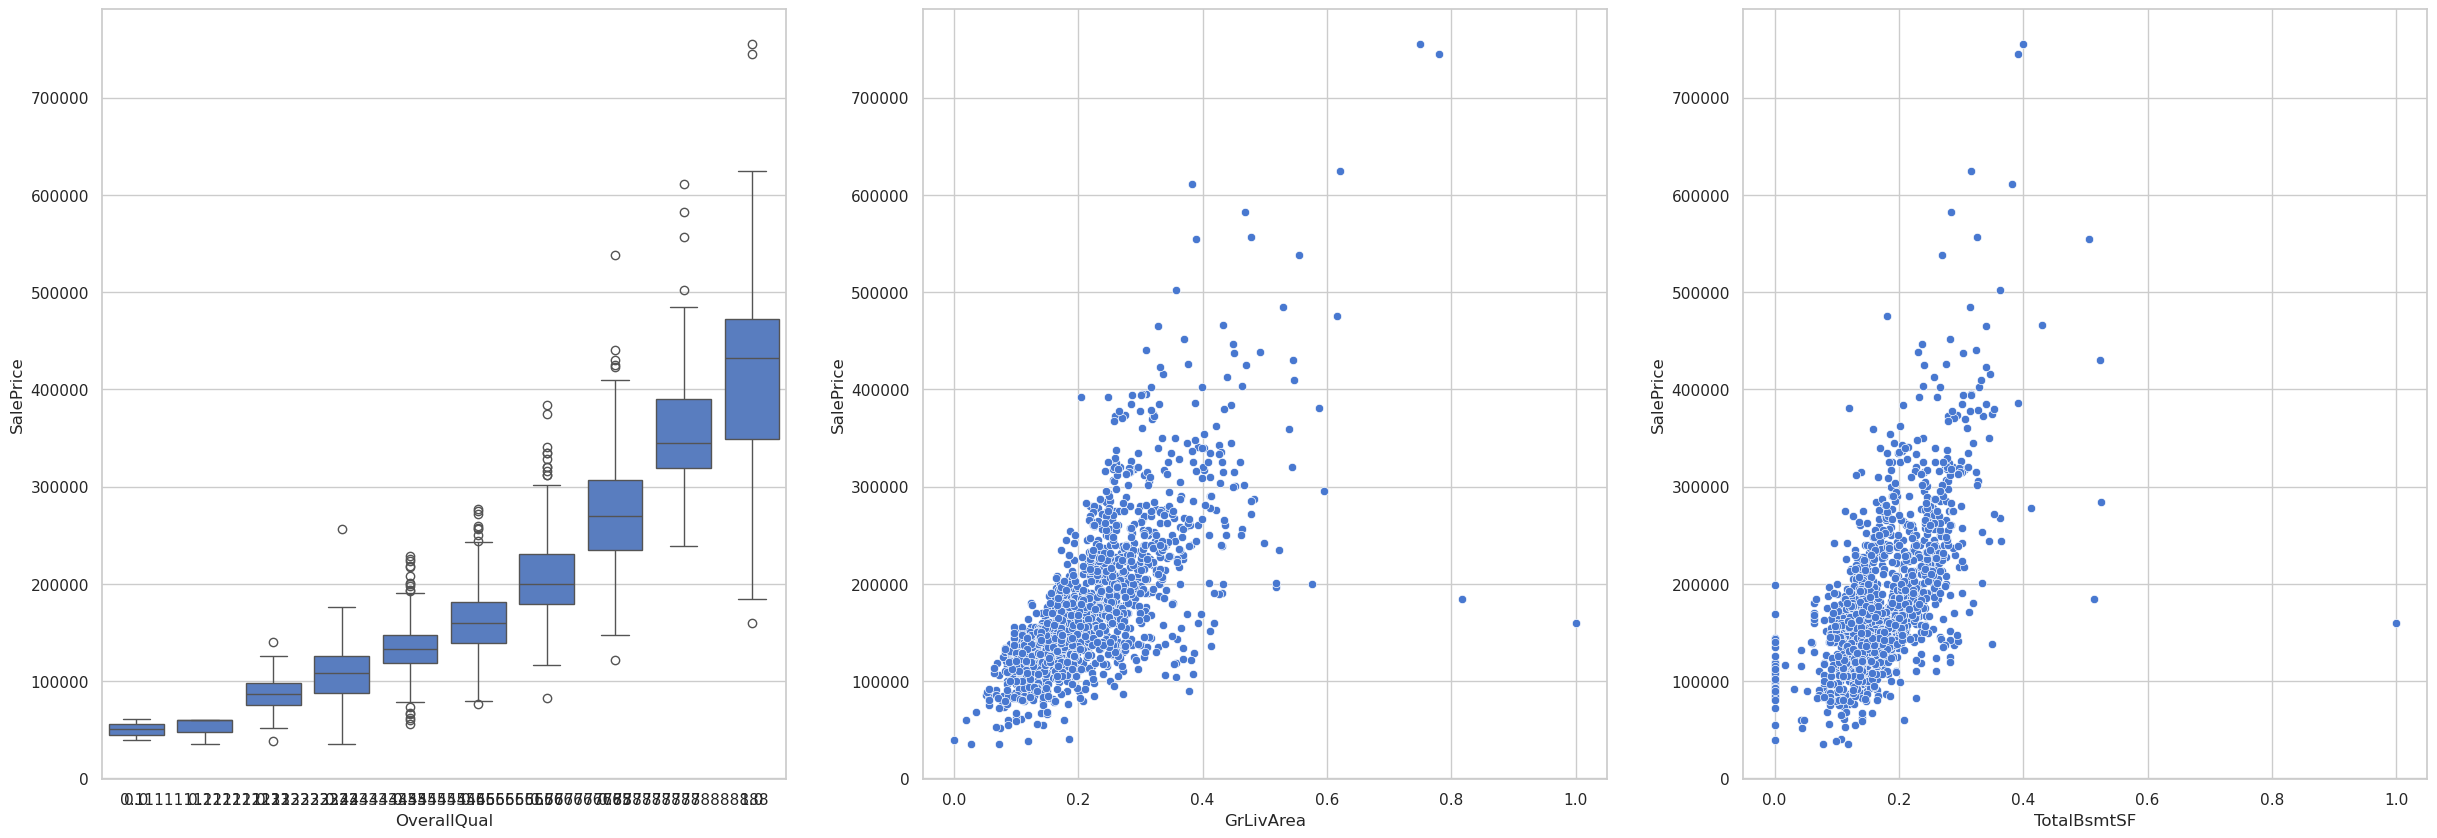

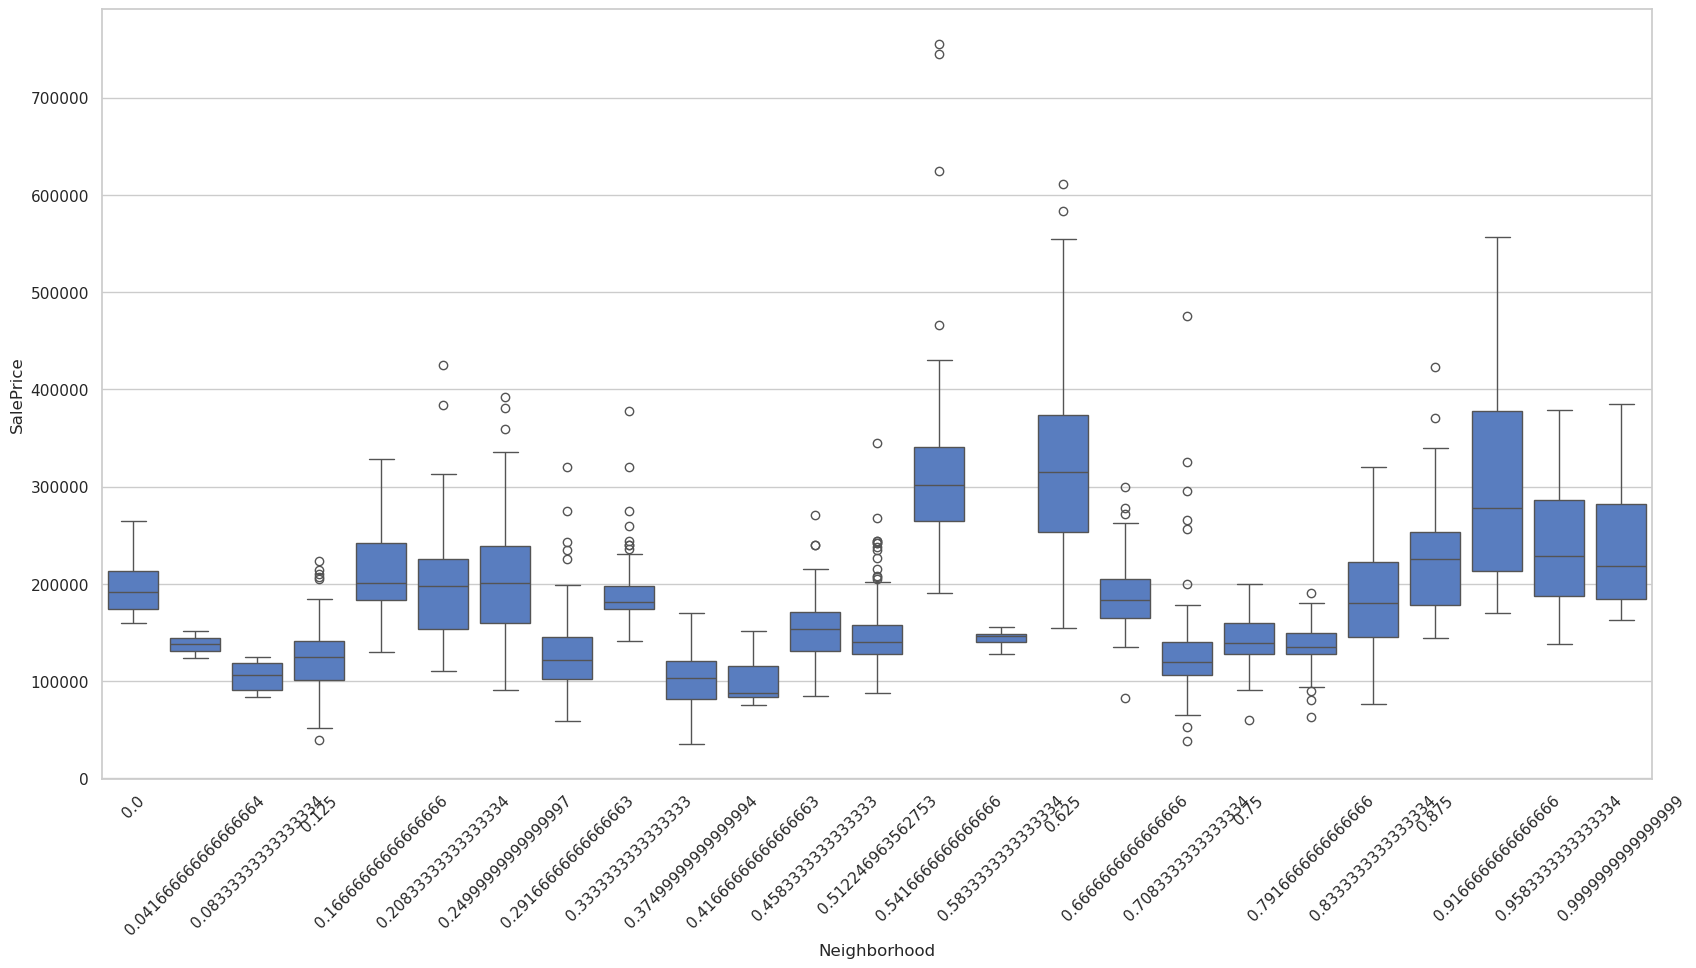

In [ ]:
sns.set(style="whitegrid", palette="muted")  
fig, axs = plt.subplots(1, 3, figsize=(30, 10))

sns.boxplot(x=train['OverallQual'],y=label,ax=axs[0])
sns.scatterplot(x=train['GrLivArea'],y=label,ax=axs[1])
sns.scatterplot(x=train['TotalBsmtSF'],y=label,ax=axs[2])

plt.figure(figsize=(20,10))
sns.boxplot(x=train['Neighborhood'],y=label)
plt.xticks(rotation=45)
plt.show()

#### Features Heatmap

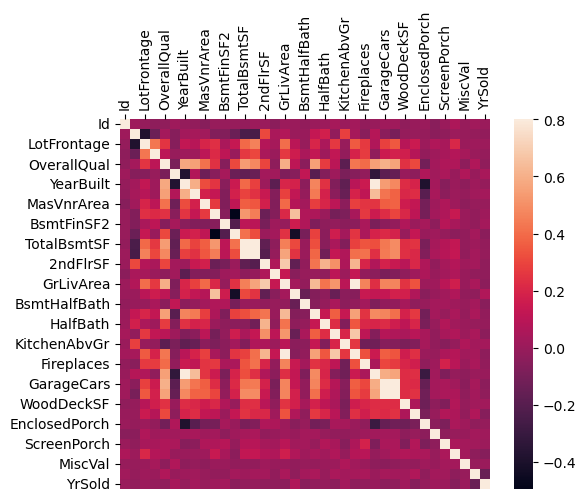

<Figure size 1200x1200 with 0 Axes>

In [7]:
ax = sns.heatmap(train.select_dtypes(include=['number']).corr(),square=True,vmax=0.8)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xticks(rotation=90)
plt.figure(figsize=(12,12))
plt.show()

## Encoding

In [ ]:
encode = {
    "MSZoning": {"A": 1, "C": 2, "FV": 3, "I": 4, "RH": 5, "RL": 6, "RP": 7, "RM": 8},
    "Street": {"Grvl": 1, "Pave": 2},
    "Alley": {"Grvl": 1, "Pave": 2, "NA": 0},
    "LotShape": {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1},
    "LandContour": {"Lvl": 4, "Bnk": 3, "HLS": 2, "Low": 1},
    "Utilities": {"AllPub": 4, "NoSewr": 3, "NoSeWa": 2, "ELO": 1},
    "LotConfig": {"Inside": 1, "Corner": 2, "CulDSac": 3, "FR2": 4, "FR3": 5},
    "LandSlope": {"Gtl": 3, "Mod": 2, "Sev": 1},
    "Neighborhood": {
        "Blmngtn": 1, "Blueste": 2, "BrDale": 3, "BrkSide": 4, "ClearCr": 5, "CollgCr": 6,
        "Crawfor": 7, "Edwards": 8, "Gilbert": 9, "IDOTRR": 10, "MeadowV": 11, "Mitchel": 12,
        "Names": 13, "NoRidge": 14, "NPkVill": 15, "NridgHt": 16, "NWAmes": 17, "OldTown": 18,
        "SWISU": 19, "Sawyer": 20, "SawyerW": 21, "Somerst": 22, "StoneBr": 23, "Timber": 24,
        "Veenker": 25
    },
    "Condition1": {
        "Artery": 1, "Feedr": 2, "Norm": 3, "RRNn": 4, "RRAn": 5, "PosN": 6, "PosA": 7,
        "RRNe": 8, "RRAe": 9
    },
    "Condition2": {
        "Artery": 1, "Feedr": 2, "Norm": 3, "RRNn": 4, "RRAn": 5, "PosN": 6, "PosA": 7,
        "RRNe": 8, "RRAe": 9
    },
    "BldgType": {"1Fam": 1, "2FmCon": 2, "Duplx": 3, "TwnhsE": 4, "TwnhsI": 5},
    "HouseStyle": {
        "1Story": 1, "1.5Fin": 2, "1.5Unf": 3, "2Story": 4, "2.5Fin": 5, "2.5Unf": 6,
        "SFoyer": 7, "SLvl": 8
    },
    "RoofStyle": {"Flat": 1, "Gable": 2, "Gambrel": 3, "Hip": 4, "Mansard": 5, "Shed": 6},
    "RoofMatl": {
        "ClyTile": 1, "CompShg": 2, "Membran": 3, "Metal": 4, "Roll": 5, "Tar&Grv": 6,
        "WdShake": 7, "WdShngl": 8
    },
    "Exterior1st": {
        "AsbShng": 1, "AsphShn": 2, "BrkComm": 3, "BrkFace": 4, "CBlock": 5, "CemntBd": 6,
        "HdBoard": 7, "ImStucc": 8, "MetalSd": 9, "Other": 10, "Plywood": 11, "PreCast": 12,
        "Stone": 13, "Stucco": 14, "VinylSd": 15, "Wd Sdng": 16, "WdShing": 17
    },
    "Exterior2nd": {
        "AsbShng": 1, "AsphShn": 2, "BrkComm": 3, "BrkFace": 4, "CBlock": 5, "CemntBd": 6,
        "HdBoard": 7, "ImStucc": 8, "MetalSd": 9, "Other": 10, "Plywood": 11, "PreCast": 12,
        "Stone": 13, "Stucco": 14, "VinylSd": 15, "Wd Sdng": 16, "WdShing": 17
    },
    "MasVnrType": {"BrkCmn": 1, "BrkFace": 2, "CBlock": 3, "None": 0, "Stone": 4},
    "ExterQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "ExterCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "Foundation": {"BrkTil": 1, "CBlock": 2, "PConc": 3, "Slab": 4, "Stone": 5, "Wood": 6},
    "BsmtQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0},
    "BsmtCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0},
    "BsmtExposure": {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "NA": 0},
    "BsmtFinType1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "NA": 0},
    "BsmtFinType2": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "NA": 0},
    "Heating": {"Floor": 1, "GasA": 2, "GasW": 3, "Grav": 4, "OthW": 5, "Wall": 6},
    "HeatingQC": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "CentralAir": {"N": 0, "Y": 1},
    "Electrical": {"SBrkr": 5, "FuseA": 4, "FuseF": 3, "FuseP": 2, "Mix": 1},
    "KitchenQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "Functional": {"Typ": 8, "Min1": 7, "Min2": 6, "Mod": 5, "Maj1": 4, "Maj2": 3, "Sev": 2, "Sal": 1},
    "FireplaceQu": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0},
    "GarageType": {
        "2Types": 6, "Attchd": 5, "Basment": 4, "BuiltIn": 3, "CarPort": 2, "Detchd": 1, "NA": 0
    },
    "GarageFinish": {"Fin": 3, "RFn": 2, "Unf": 1, "NA": 0},
    "GarageQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0},
    "GarageCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0},
    "PavedDrive": {"Y": 3, "P": 2, "N": 1},
    "PoolQC": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "NA": 0},
    "Fence": {"GdPrv": 4, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "NA": 0},
    "MiscFeature": {"Elev": 4, "Gar2": 3, "Othr": 2, "Shed": 1, "TenC": 5, "NA": 0},
    "SaleType": {
        "WD": 1, "CWD": 2, "VWD": 3, "New": 4, "COD": 5, "Con": 6, "ConLw": 7, "ConLI": 8,
        "ConLD": 9, "Oth": 10
    },
    "SaleCondition": {
        "Normal": 1, "Abnorml": 2, "AdjLand": 3, "Alloca": 4, "Family": 5, "Partial": 6
    }
}

for feature in encode.keys():
    train[feature] = train[feature].map(encode[feature])
    train[feature] = train[feature].astype('float64')
    
    test[feature] = test[feature].map(encode[feature])
    test[feature] = test[feature].astype('float64')

## Imputation

In [9]:
imputer = KNNImputer(n_neighbors=5,weights='distance')

for feature in train.select_dtypes(include=['number']).columns:
    if train[feature].isnull().any():
        train[feature] = imputer.fit_transform(train[[feature]])


for feature in test.select_dtypes(include=['number']).columns:
    if test[feature].isnull().any():
        test[feature] = imputer.fit_transform(test[[feature]])


## Feature Selection

In [10]:
feature_remove = ['Id']
test_id = test['Id']
train.drop(columns=feature_remove, inplace = True)
test.drop(columns=feature_remove, inplace = True)

## Feature Scaling

In [11]:
ss= MinMaxScaler()

train = pd.DataFrame(ss.fit_transform(train),columns=train.columns)
test = pd.DataFrame(ss.fit_transform(test),columns= test.columns)

## SelectKBest

In [12]:
skb= SelectKBest(k=40)
skb.fit(train,label.to_numpy().ravel())

print(pd.DataFrame({
    'feature': train.columns,
    'SelectKBest': skb.scores_
}).sort_values(by='SelectKBest',ascending=False))

# train = pd.DataFrame(skb.fit_transform(train,label.to_numpy().ravel()),columns=train.columns[skb.get_support()])
# test = pd.DataFrame(skb.transform(test),columns=test.columns[skb.get_support()])

          feature  SelectKBest
16    OverallQual     5.729183
74        MiscVal     3.756250
26      ExterQual     3.729438
45      GrLivArea     3.435110
78  SaleCondition     3.408029
3         LotArea     3.285852
52    KitchenQual     3.124488
29       BsmtQual     2.925698
60     GarageCars     2.861594
48       FullBath     2.678847
61     GarageArea     2.583341
42       1stFlrSF     2.338620
37    TotalBsmtSF     2.315290
18      YearBuilt     2.310198
25     MasVnrArea     1.987793
59   GarageFinish     1.983050
53   TotRmsAbvGrd     1.873132
4          Street     1.870717
19   YearRemodAdd     1.827603
58    GarageYrBlt     1.808320
24     MasVnrType     1.760423
33     BsmtFinSF1     1.694719
43       2ndFlrSF     1.663993
55     Fireplaces     1.640720
40     CentralAir     1.572276
1        MSZoning     1.562414
6        LotShape     1.557782
28     Foundation     1.498846
38        Heating     1.479721
31   BsmtExposure     1.467915
36      BsmtUnfSF     1.454348
66    Op

## Fitting

#### Random Forest

In [13]:
rfr = RandomForestRegressor(criterion= 'absolute_error', max_depth= 10, min_samples_split= 2, n_estimators= 120)
rfr.fit(train,label)

feature_importances= pd.Series(rfr.feature_importances_)
print(pd.DataFrame({
    'feature': train.columns,
    'importance': feature_importances.apply(lambda x: round(x,5))
    }).sort_values(by='importance',ascending=False))

          feature  importance
16    OverallQual     0.38378
45      GrLivArea     0.11904
37    TotalBsmtSF     0.05668
61     GarageArea     0.03771
33     BsmtFinSF1     0.03362
60     GarageCars     0.02894
42       1stFlrSF     0.02877
3         LotArea     0.02291
18      YearBuilt     0.02077
43       2ndFlrSF     0.01531
59   GarageFinish     0.01466
19   YearRemodAdd     0.01290
2     LotFrontage     0.01150
36      BsmtUnfSF     0.01148
17    OverallCond     0.01067
57     GarageType     0.01066
29       BsmtQual     0.01046
25     MasVnrArea     0.00995
58    GarageYrBlt     0.00932
11   Neighborhood     0.00930
66    OpenPorchSF     0.00928
65     WoodDeckSF     0.00764
55     Fireplaces     0.00732
75         MoSold     0.00703
53   TotRmsAbvGrd     0.00575
32   BsmtFinType1     0.00570
1        MSZoning     0.00496
23    Exterior2nd     0.00482
52    KitchenQual     0.00472
31   BsmtExposure     0.00461
48       FullBath     0.00419
22    Exterior1st     0.00393
50   Bedro

#### Gradient Boosting

In [14]:
gbr = GradientBoostingRegressor(min_samples_split=5)
gbr.fit(train,label)

GradientBoostingRegressor(min_samples_split=5)

#### XG Boost

In [15]:
xgbr = XGBRegressor()
xgbr.fit(train,label)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

#### light gbm

In [16]:
lgbmr = LGBMRegressor(objective='regression',learning_rate=0.1,max_depth=-1,num_leaves=31,n_estimators=100)
lgbmr.fit(train,label)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3386
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 74
[LightGBM] [Info] Start training from score 180921.195890


LGBMRegressor(objective='regression')

#### Support Vector Machine

In [17]:
svr = SVR(C=0.1)
svr.fit(train,label)

SVR(C=0.1)

#### Lasso

In [18]:
l = Lasso(fit_intercept=False)
l.fit(train,label)

/home/anshul/Documents/anaconda3/envs/kaggle/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.334e+11, tolerance: 5.700e+09
  model = cd_fast.enet_coordinate_descent(


Lasso(fit_intercept=False)

#### Ridge

In [19]:
r = Ridge(fit_intercept=False)
r.fit(train,label)

Ridge(fit_intercept=False)

#### Multi-Layer Perceptron Regressor

In [20]:
mlpr = MLPRegressor(
    hidden_layer_sizes=(128,64,32),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=500,
    random_state=42
)
mlpr.fit(train,label)

/home/anshul/Documents/anaconda3/envs/kaggle/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(128, 64, 32), learning_rate='adaptive',
             max_iter=500, random_state=42)

## Actual vs Predicted SalePrice
(on training set)

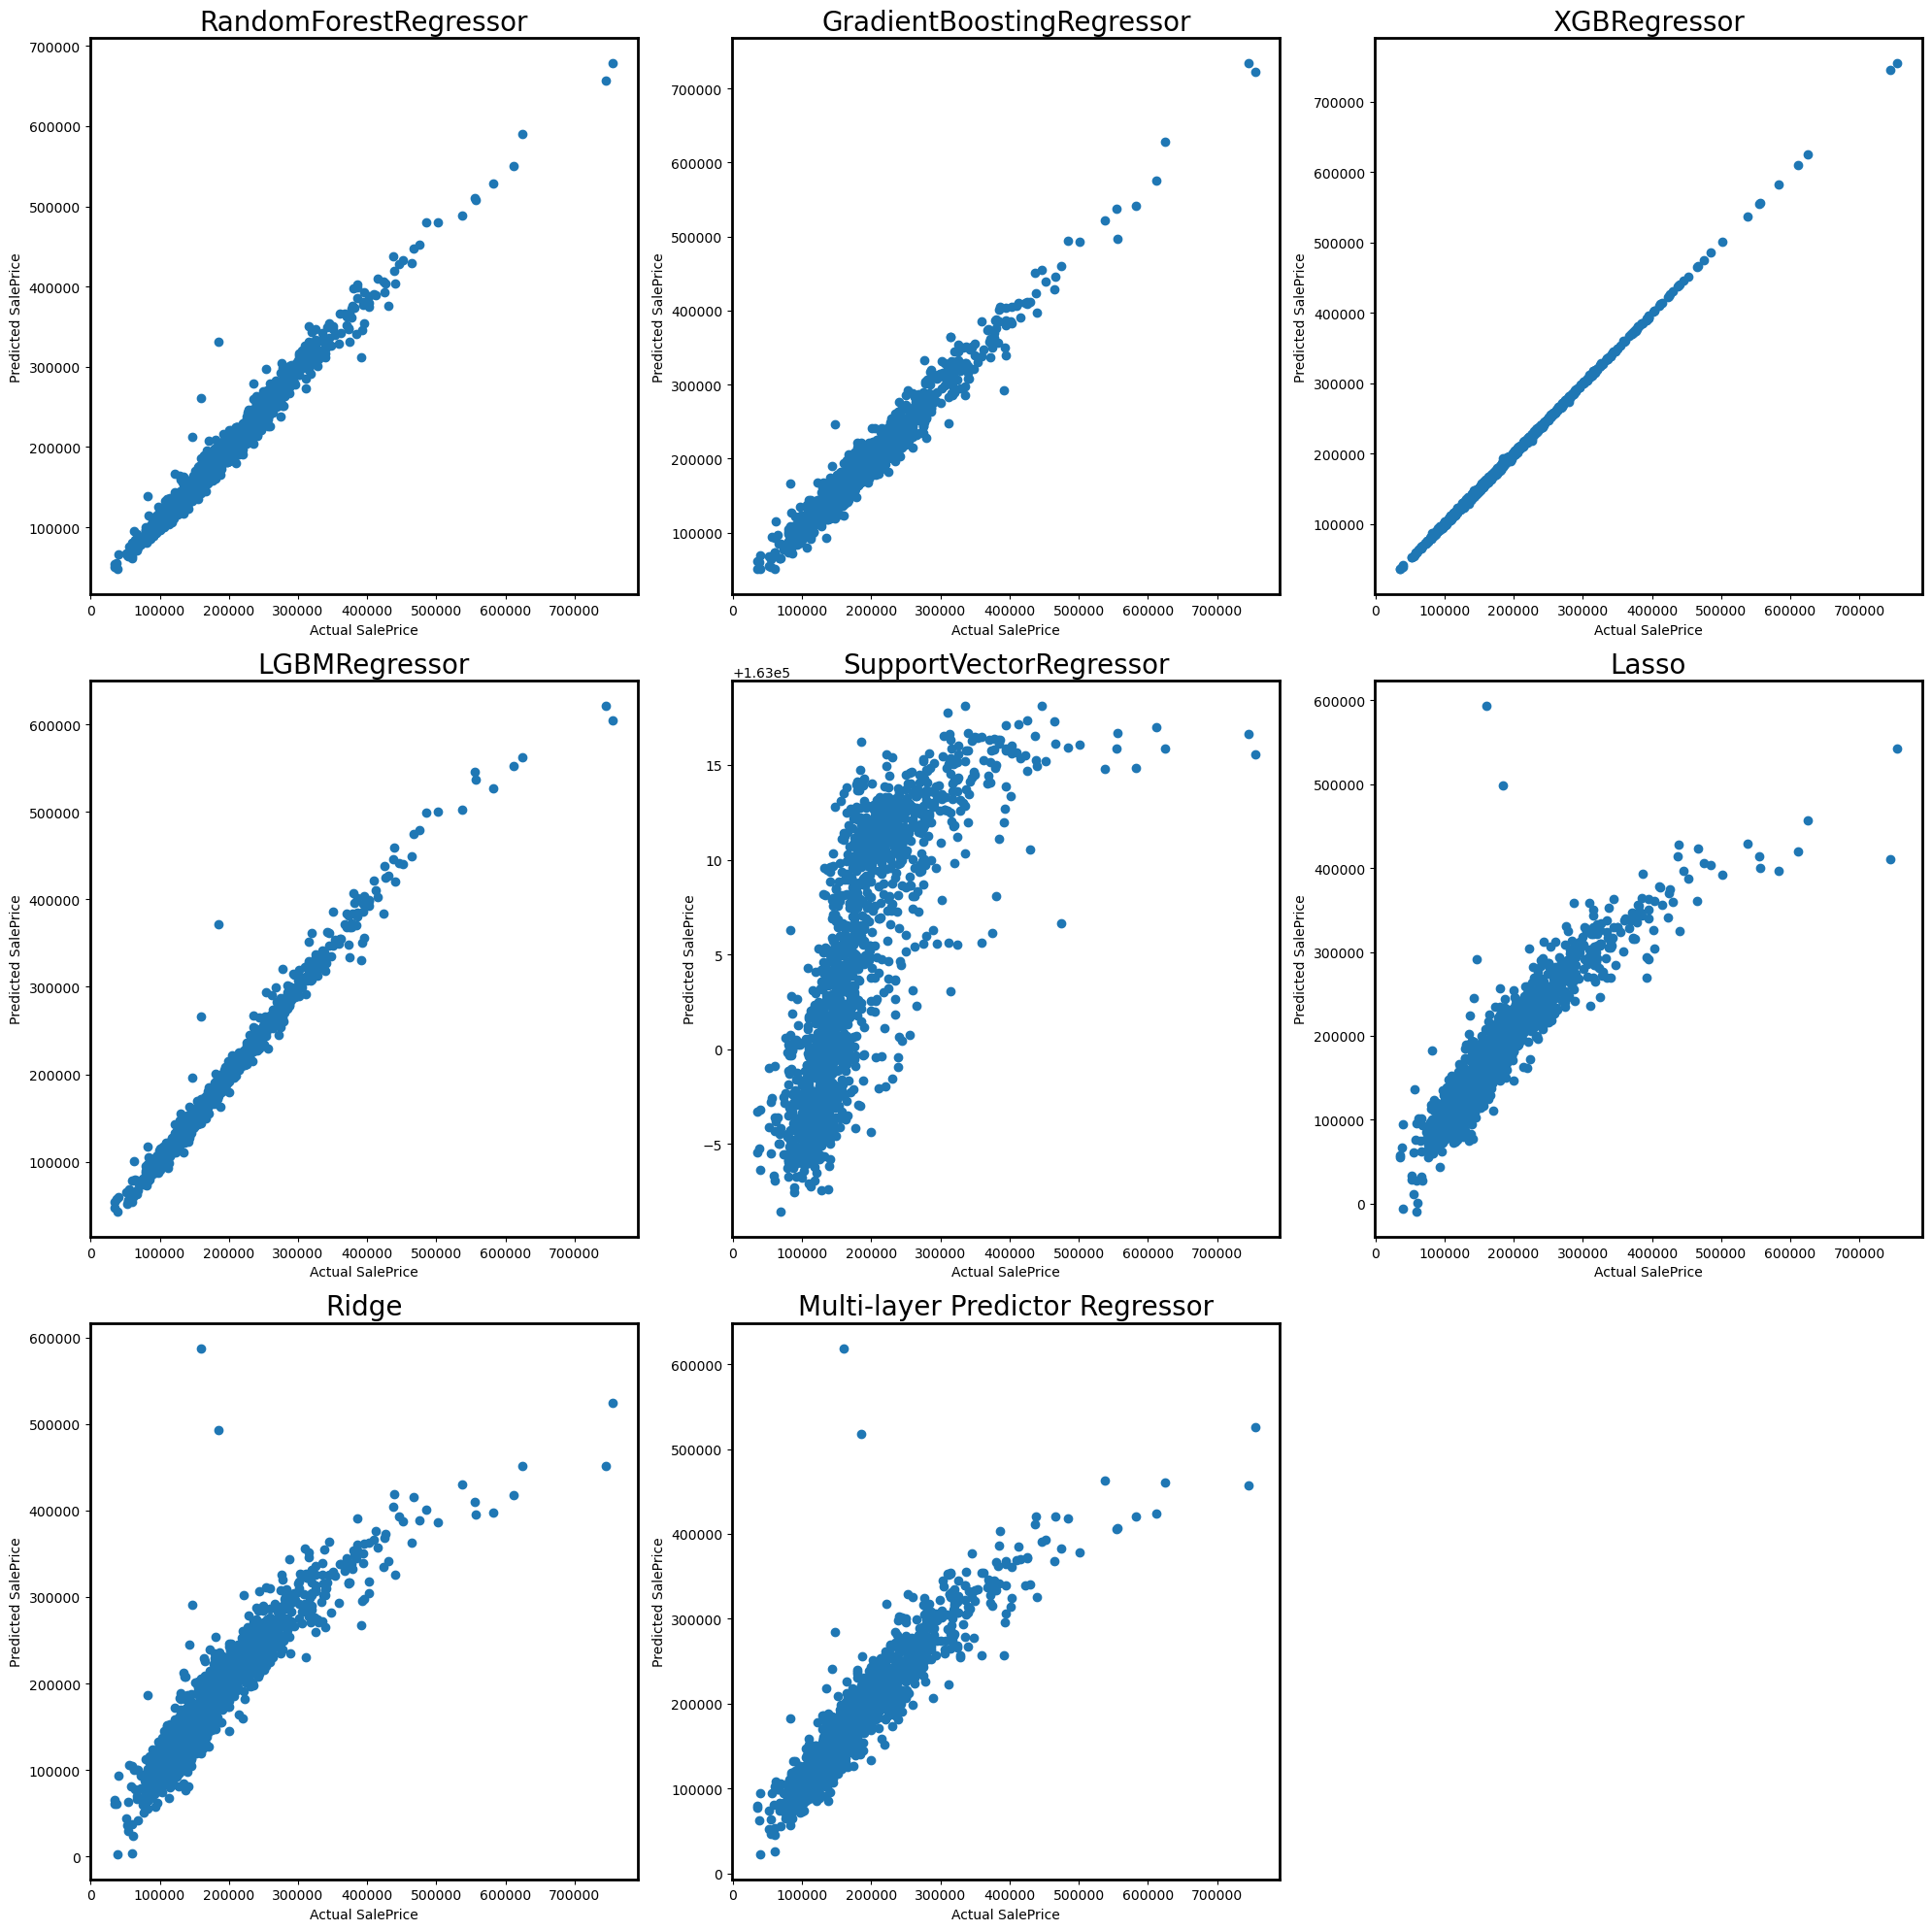

In [28]:
fig, axs = plt.subplots(3, 3, figsize=(20, 20))
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.3, hspace=0.3)

# Set uniform spine properties
for ax in axs.flat:
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

# Define models and their subplot positions
models = [
    (rfr, 'RandomForestRegressor', (0, 0)),
    (gbr, 'GradientBoostingRegressor', (0, 1)),
    (xgbr, 'XGBRegressor', (0, 2)),
    (lgbmr, 'LGBMRegressor', (1, 0)),
    (svr, 'SupportVectorRegressor', (1, 1)),
    (l, 'Lasso', (1, 2)),
    (r, 'Ridge', (2, 0)),
    (mlpr, 'Multi-layer Predictor Regressor', (2, 1))
]

# Plot predictions against actual values
for model, title, pos in models:
    axs[pos].scatter(label, model.predict(train))
    axs[pos].set(xlabel='Actual SalePrice', ylabel='Predicted SalePrice', title=title)
    axs[pos].title.set_fontsize(20)

# Turn off the unused subplot
axs[2, 2].axis('off')

plt.tight_layout()
plt.show()

## Write Predictions File

In [22]:
predictions= pd.DataFrame({
    'Id' : test_id,
    'SalePrice' : mlpr.predict(test)
})

predictions.to_csv('submission.csv',index=False)